In [1]:
import torch
import mylib

from torch import nn

In [2]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss(reduction='none')

def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
              f'loss: {mylib.evaluate_loss(net, train_iter, loss):f}')

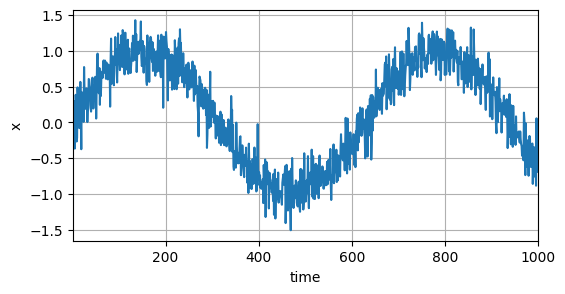

In [3]:
T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
mylib.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [4]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = mylib.load_array((features[:n_train], labels[:n_train]), 
                              batch_size, is_train=True)

In [5]:
net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 0.064824
epoch 2, loss: 0.060331
epoch 3, loss: 0.056985
epoch 4, loss: 0.061177
epoch 5, loss: 0.055379


In [6]:
-7 // 2

-4